In [1]:
import glob
import os
import shutil
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from monai.config import print_config
from monai.data import DataLoader, Dataset, CacheDataset
from monai.data.image_reader import NibabelReader, ITKReader
from monai.inferers import sliding_window_inference
from monai.losses import PatchAdversarialLoss, PerceptualLoss
from monai.networks.nets import AutoencoderKL, DiffusionModelUNet, PatchDiscriminator
from monai.networks.schedulers import DDPMScheduler
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    LoadImaged,
    Orientationd,
    RandSpatialCropd,
    ScaleIntensityRanged,
    Spacingd,
    ToTensord,
)
from monai.utils import set_determinism
from sklearn.model_selection import train_test_split
from tqdm import tqdm

print_config()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

2026-01-04 17:50:49.990913: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-04 17:50:51.113876: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


MONAI version: 1.5.1
Numpy version: 2.3.5
Pytorch version: 2.9.1
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 9c6d819f97e37f36c72f3bdfad676b455bd2fa0d
MONAI __file__: /home/<username>/projects/ood-detection/.venv/lib/python3.13/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: 5.4.4
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 12.0.0
Tensorboard version: 2.20.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.24.1
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.1.3
pandas version: 2.3.1
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependenc

# Data Loading

We will load ATLAS_2 data as In-Distribution (ID) and CHAOS data as Out-of-Distribution (OOD).

**Training Strategy:**
- **Train/Val (ID)**: Random 64x64x64 crops
- **Test (ID/OOD)**: Full volumes (sliding window inference)

In [2]:
# --- ATLAS_2 Data Loading (In-Distribution) ---
nibabel_reader = NibabelReader()
data_dir = Path("data/ATLAS_2/Training")

image_files = sorted(glob.glob(str(data_dir / "**/*_T1w.nii.gz"), recursive=True))
mask_files = sorted(glob.glob(str(data_dir / "**/*_label-L_desc-T1lesion_mask.nii.gz"), recursive=True))

# Using a subset for faster demonstration if needed, but here we load all
indistribution_data = [
    {"image": img, "label": mask}
    for img, mask in zip(image_files, mask_files)
]

# Split into train/val/test
train_data, val_test_data = train_test_split(indistribution_data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(val_test_data, test_size=0.5, random_state=42)

print(f"ATLAS_2 - Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Transforms
# Reduced from 96 to 64 to fit in 4GB VRAM
spatial_size = (64, 64, 64)

train_transforms = Compose([
    LoadImaged(keys=["image"], reader=nibabel_reader),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
    Orientationd(keys=["image"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    RandSpatialCropd(keys=["image"], roi_size=spatial_size, random_size=False),
    ToTensord(keys=["image"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image"], reader=nibabel_reader),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
    Orientationd(keys=["image"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    ToTensord(keys=["image"]),
])

# Reduce cache rate or num_workers if memory issues arise
# Reduced num_workers to 2 to verify if it helps stability
train_ds = CacheDataset(data=train_data, transform=train_transforms, cache_rate=0.2, num_workers=4)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2)

val_ds = CacheDataset(data=val_data, transform=val_transforms, cache_rate=0.2, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=1)

test_ds = CacheDataset(data=test_data, transform=val_transforms, cache_rate=0.0, num_workers=1)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=1)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


ATLAS_2 - Train: 524, Val: 65, Test: 66


Loading dataset: 100%|██████████| 13/13 [00:01<00:00, 10.30it/s]


In [9]:
# --- CHAOS Data Loading (Out-of-Distribution) ---
dicom_reader = ITKReader()
chaos_base_dir = Path("data/chaos")

def collect_ct_data(ct_dir):
    ct_data = []
    if not ct_dir.exists(): return ct_data
    patient_dirs = sorted([d for d in ct_dir.iterdir() if d.is_dir() and d.name.isdigit()])
    for patient_dir in patient_dirs:
        dicom_dir = patient_dir / "DICOM_anon"
        if dicom_dir.exists() and len(list(dicom_dir.glob("*.dcm"))) > 0:
            ct_data.append({"image": str(dicom_dir), "modality": "CT"})
    return ct_data

def collect_mr_data(mr_dir):
    mr_data = []
    if not mr_dir.exists(): return mr_data
    patient_dirs = sorted([d for d in mr_dir.iterdir() if d.is_dir() and d.name.isdigit()])
    for patient_dir in patient_dirs:
        for sequence in ["T1DUAL", "T2SPIR"]:
            seq_dir = patient_dir / sequence
            if seq_dir.exists() and len(list(seq_dir.glob("*.dcm"))) > 0:
                mr_data.append({"image": str(seq_dir), "modality": "MR", "sequence": sequence})
    return mr_data

chaos_data = []
chaos_data.extend(collect_ct_data(chaos_base_dir / "CHAOS_Train_Sets" / "Train_Sets" / "CT"))
chaos_data.extend(collect_ct_data(chaos_base_dir / "CHAOS_Test_Sets" / "Test_Sets" / "CT"))
chaos_data.extend(collect_mr_data(chaos_base_dir / "CHAOS_Train_Sets" / "Train_Sets" / "MR"))
chaos_data.extend(collect_mr_data(chaos_base_dir / "CHAOS_Test_Sets" / "Test_Sets" / "MR"))

print(f"CHAOS (OOD) - Total Volumes: {len(chaos_data)}")

chaos_transforms = Compose([
    LoadImaged(keys=["image"], reader=dicom_reader),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
    Orientationd(keys=["image"], axcodes="RAS"),
    # Note: CHAOS includes CT (HU) and portions of MR. Simple 0-1 scaling for now.
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    RandSpatialCropd(keys=["image"], roi_size=spatial_size, random_size=False),
    ToTensord(keys=["image"]),
])

chaos_ds = CacheDataset(data=chaos_data, transform=chaos_transforms, cache_rate=0.0, num_workers=1)
chaos_loader = DataLoader(chaos_ds, batch_size=1, shuffle=False, num_workers=1)

CHAOS (OOD) - Total Volumes: 40


# Model Architecture

1. **AutoencoderKL**: Compresses 3D scan to latent representation.
2. **DiffusionModelUNet**: Denoising model operating in latent space.

In [4]:
# Significantly reduced capacity to fit in 4GB VRAM
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 64),
    latent_channels=3,
    num_res_blocks=1,
    attention_levels=(False, False, False),
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
).to(device)

# Training Loops

We split training into two stages:
1. Train AutoencoderKL
2. Train DiffusionModelUNet on latents

In [ ]:
# --- Stage 1: Train AutoencoderKL ---
# Note: In a real scenario, train for significantly more epochs

optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
recon_loss_fn = torch.nn.MSELoss()
kl_weight = 1e-6

n_epochs_ae = 5  # Reduced for demonstration

print("Starting AutoencoderKL Training...")
autoencoder.train()

for epoch in range(n_epochs_ae):
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs_ae}")
    for batch in progress_bar:
        images = batch["image"].to(device)
        optimizer_ae.zero_grad()
        
        reconstruction, z_mu, z_sigma = autoencoder(images)
        
        recons_loss = recon_loss_fn(reconstruction, images)
        kl_loss = 0.5 * torch.sum(z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2)) - 1, dim=[1, 2, 3, 4])
        kl_loss = torch.mean(kl_loss)
        
        loss = recons_loss + kl_weight * kl_loss
        loss.backward()
        optimizer_ae.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})
        
    print(f"Epoch {epoch+1} finished. Avg Loss: {epoch_loss / len(train_loader):.4f}")

# Save AE weights
torch.save(autoencoder.state_dict(), "autoencoder.pth")

Starting AutoencoderKL Training...


Epoch 1/5: 100%|██████████| 524/524 [02:01<00:00,  4.32it/s, loss=0.000882]


Epoch 1 finished. Avg Loss: 0.0037


Epoch 2/5: 100%|██████████| 524/524 [02:04<00:00,  4.21it/s, loss=0.000444]


Epoch 2 finished. Avg Loss: 0.0007


...

Epoch 3 finished. Avg Loss: 0.0005


Epoch 4/5: 100%|██████████| 524/524 [02:08<00:00,  4.06it/s, loss=0.00055] 


Epoch 4 finished. Avg Loss: 0.0005


Epoch 5/5: 100%|██████████| 524/524 [02:08<00:00,  4.07it/s, loss=0.00046] 

Epoch 5 finished. Avg Loss: 0.0005


In [5]:
autoencoder.load_state_dict(torch.load("autoencoder.pth"))

<All keys matched successfully>

In [ ]:
batch = next(iter(train_loader))
image = batch["image"].to(device)
reconstruction, _, _ = autoencoder(image)
reconstruction


metatensor([[[[[0.0606, 0.0671, 0.0689,  ..., 0.0611, 0.0648, 0.0178],
           [0.0238, 0.0276, 0.0323,  ..., 0.0283, 0.0309, 0.0040],
           [0.0187, 0.0239, 0.0289,  ..., 0.0281, 0.0291, 0.0050],
           ...,
           [0.0257, 0.0314, 0.0352,  ..., 0.0305, 0.0299, 0.0093],
           [0.0193, 0.0330, 0.0361,  ..., 0.0341, 0.0329, 0.0189],
           [0.0136, 0.0141, 0.0210,  ..., 0.0151, 0.0151, 0.0701]],

          [[0.0149, 0.0270, 0.0294,  ..., 0.0259, 0.0222, 0.0120],
           [0.0401, 0.0362, 0.0376,  ..., 0.0366, 0.0351, 0.0095],
           [0.0365, 0.0342, 0.0363,  ..., 0.0360, 0.0324, 0.0113],
           ...,
           [0.0358, 0.0336, 0.0355,  ..., 0.0359, 0.0335, 0.0155],
           [0.0299, 0.0376, 0.0363,  ..., 0.0409, 0.0379, 0.0275],
           [0.0406, 0.0255, 0.0287,  ..., 0.0285, 0.0327, 0.0646]],

          [[0.0104, 0.0294, 0.0311,  ..., 0.0316, 0.0264, 0.0217],
           [0.0390, 0.0384, 0.0384,  ..., 0.0408, 0.0365, 0.0150],
           [0.0373, 0.

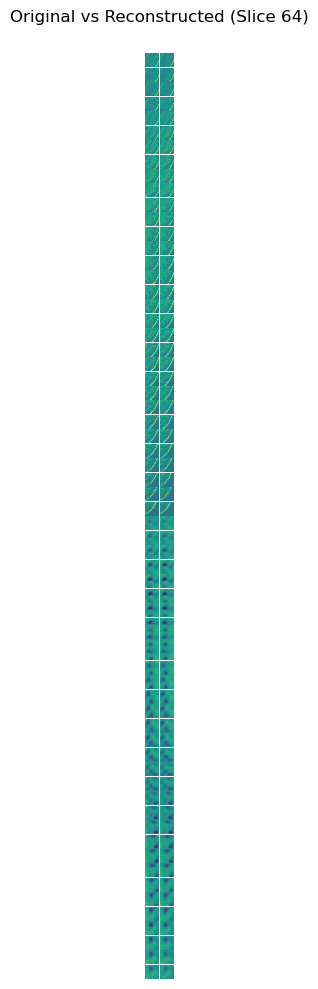

(<Figure size 1000x1000 with 1 Axes>,
 array([[       nan,        nan,        nan, ...,        nan,        nan,
                nan],
        [       nan, 0.01759066, 0.01600452, ..., 0.03656498, 0.03810023,
                nan],
        [       nan, 0.01446927, 0.01267108, ..., 0.03765069, 0.03858371,
                nan],
        ...,
        [       nan, 0.0227131 , 0.03757855, ..., 0.0138304 , 0.02329435,
                nan],
        [       nan, 0.03345221, 0.02130958, ..., 0.04691317, 0.06280093,
                nan],
        [       nan,        nan,        nan, ...,        nan,        nan,
                nan]], shape=(4224, 132), dtype=float32))

In [8]:
from monai.visualize import matshow3d

# Assuming 'images' is your original batch and 'recons' is the model output
# We pick a specific slice index (e.g., the middle slice 64 of a 128-sized volume)
original_slice = image[0, 0, :, :, :].detach().cpu()
reconstructed_slice = reconstruction[0, 0, :, :, :].detach().cpu()

matshow3d(
    volume=[original_slice, reconstructed_slice], 
    title="Original vs Reconstructed (Slice 64)",
    frames_per_row=2, 
    show=True
)

In [6]:
# Significantly reduced capacity
unet = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=3,
    out_channels=3,
    channels=(32, 64, 128),
    num_res_blocks=1,
    attention_levels=(False, False, True),
).to(device)

scheduler = DDPMScheduler(num_train_timesteps=1000, schedule="linear_beta", beta_start=0.0015, beta_end=0.0195)

In [7]:
# --- Stage 2: Train Diffusion Model ---

optimizer_unet = torch.optim.Adam(unet.parameters(), lr=1e-4)
n_epochs_diff = 10 # Increased epochs
accumulation_steps = 4 # Gradient accumulation for stability

print("Starting Diffusion Model Training...")
autoencoder.eval()
unet.train()

for epoch in range(n_epochs_diff):
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs_diff}")
    
    optimizer_unet.zero_grad()
    
    for step, batch in enumerate(progress_bar):
        images = batch["image"].to(device)
        
        # 1. Get Latents
        with torch.no_grad():
            z_mu, z_sigma = autoencoder.encode(images)
            z = autoencoder.sampling(z_mu, z_sigma)
            
        # 2. Add Noise
        noise = torch.randn_like(z).to(device)
        timesteps = torch.randint(0, scheduler.num_train_timesteps, (z.shape[0],), device=device).long()
        noisy_z = scheduler.add_noise(original_samples=z, noise=noise, timesteps=timesteps)
        
        # 3. Denoise
        noise_pred = unet(x=noisy_z, timesteps=timesteps)
        
        loss = F.mse_loss(noise_pred, noise)
        
        # Gradient Accumulation
        loss = loss / accumulation_steps
        loss.backward()
        
        if (step + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
            optimizer_unet.step()
            optimizer_unet.zero_grad()
        
        epoch_loss += loss.item() * accumulation_steps
        progress_bar.set_postfix({"loss": loss.item() * accumulation_steps})

    print(f"Epoch {epoch+1} finished. Avg Loss: {epoch_loss / len(train_loader):.4f}")

# Save Diffusion weights
torch.save(unet.state_dict(), "diffusion_unet.pth")

Starting Diffusion Model Training...


Epoch 1/10: 100%|██████████| 524/524 [00:39<00:00, 13.28it/s, loss=0.238]


Epoch 1 finished. Avg Loss: 0.6259


Epoch 2/10: 100%|██████████| 524/524 [00:39<00:00, 13.37it/s, loss=0.112] 


Epoch 2 finished. Avg Loss: 0.3393


...

Epoch 8 finished. Avg Loss: 0.2465


Epoch 9/10: 100%|██████████| 524/524 [00:40<00:00, 13.00it/s, loss=1]     


Epoch 9 finished. Avg Loss: 0.2500


Epoch 10/10: 100%|██████████| 524/524 [00:40<00:00, 12.93it/s, loss=0.0395]


Epoch 10 finished. Avg Loss: 0.2276


In [7]:
unet.load_state_dict(torch.load("diffusion_unet.pth"))

<All keys matched successfully>

In [36]:
from monai.networks.schedulers import PNDMScheduler

batch = next(iter(train_loader))
image = batch["image"].to(device)

scheduler = PNDMScheduler(
    num_train_timesteps=1000, 
    beta_start=0.0015, 
    beta_end=0.0205, 
    prediction_type="epsilon"
)
scheduler.set_timesteps(num_inference_steps=50)

with torch.no_grad():
    z_mu, z_sigma = autoencoder.encode(image)
    z = autoencoder.sampling(z_mu, z_sigma)

mse_scores = []
mse_loss = torch.nn.MSELoss()

x_0 = image

for t in scheduler.timesteps:
    with torch.no_grad():
        # Predict noise residual using the U-Net
        # PNDM expects the time 't' to be passed as a tensor
        model_output = unet(z, timesteps=torch.Tensor((t,)).to(device))
        
        # Compute the previous noisy sample (x_t -> x_t-1)
        # The scheduler handles the complex PLMS math internally
        z, _ = scheduler.step(model_output, t, z)
        x = autoencoder.decode(z)
        mse = mse_loss(x_0, x)
        mse_scores.append(mse)

# 4. Decode the final latent back to image space
with torch.no_grad():
    # Important: Many Autoencoders require a scaling factor (e.g., 1 / 0.18215) 
    # if one was used during training to keep latent variance near 1.
    reconstructed_image = autoencoder.decode(z)

confidence_score = sum(mse_scores) / len(mse_scores)
confidence_score

metatensor(0.0006, device='cuda:0')

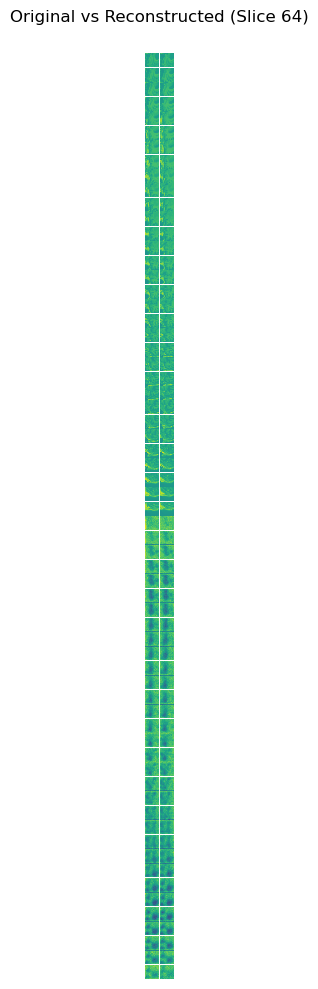

(<Figure size 1000x1000 with 1 Axes>,
 array([[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,  0.04433344,  0.04449784, ...,  0.01100093,
          0.01058993,         nan],
        [        nan,  0.03668875,  0.03648325, ...,  0.01058993,
          0.01058993,         nan],
        ...,
        [        nan,  0.02864883,  0.03717893, ...,  0.02960753,
          0.03684952,         nan],
        [        nan, -0.00562679, -0.02177314, ..., -0.00414081,
          0.0335335 ,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]], shape=(4224, 132), dtype=float32))

In [29]:
from monai.visualize import matshow3d

# Assuming 'images' is your original batch and 'recons' is the model output
# We pick a specific slice index (e.g., the middle slice 64 of a 128-sized volume)
original_slice = image[0, 0, :, :, :].detach().cpu()
reconstructed_slice = reconstructed_image[0, 0, :, :, :].detach().cpu()

matshow3d(
    volume=[original_slice, reconstructed_slice], 
    title="Original vs Reconstructed (Slice 64)",
    frames_per_row=2, 
    show=True
)

In [10]:
from monai.networks.schedulers import PNDMScheduler

batch = next(iter(chaos_loader))
image = batch["image"].to(device)

scheduler = PNDMScheduler(
    num_train_timesteps=1000, 
    beta_start=0.0015, 
    beta_end=0.0205, 
    prediction_type="epsilon"
)
scheduler.set_timesteps(num_inference_steps=50)

with torch.no_grad():
    z_mu, z_sigma = autoencoder.encode(image)
    z = autoencoder.sampling(z_mu, z_sigma)

mse_scores = []
mse_loss = torch.nn.MSELoss()

x_0 = image

for t in scheduler.timesteps:
    with torch.no_grad():
        # Predict noise residual using the U-Net
        # PNDM expects the time 't' to be passed as a tensor
        model_output = unet(z, timesteps=torch.Tensor((t,)).to(device))
        
        # Compute the previous noisy sample (x_t -> x_t-1)
        # The scheduler handles the complex PLMS math internally
        z, _ = scheduler.step(model_output, t, z)
        x = autoencoder.decode(z)
        mse = mse_loss(x_0, x)
        mse_scores.append(mse)

# 4. Decode the final latent back to image space
with torch.no_grad():
    # Important: Many Autoencoders require a scaling factor (e.g., 1 / 0.18215) 
    # if one was used during training to keep latent variance near 1.
    reconstructed_image = autoencoder.decode(z)

confidence_score = sum(mse_scores) / len(mse_scores)
confidence_score

metatensor(0.2677, device='cuda:0')